# **Additional Findings: Data Leakage**

**Purpose**
- Demonstrate how including the target variable in the feature set can lead to data leakage in the model.

**Dataset**
- Processed CALABARZON dengue dataset with climate, socioeconomic, and environmental variables.

**Process**
- Load the prepared dataset.
- Train the XGBoost classification model with the target variable included as a feature.
- Apply SHAP analysis to examine feature contributions.
- Observe how the target variable dominates the model due to data leakage.

**Output**
- Additional findings illustrating the effect of data leakage when the target variable is included in the feature set.

In [1]:
# ============================================================
# ADDITIONAL FINDINGS MODEL (WITH LEAKAGE)
# Climate + Socioeconomic + Environmental + Dengue Cases
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)

Leakage Model
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 27)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.9855
Best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 1200, 'min_child_weight': 2, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}

Hold-out accuracy: 0.9916

Classification Report
              precision    recall  f1-score   support

        High       0.95      0.96      0.95        98
         Low       1.00      1.00      1.00      1183
      Medium       0.98      0.98      0.98       380

    accuracy                           0.99      1661
   macro avg       0.98      0.98      0.98      1661
weighted avg       0.99      0.99      0.99      1661



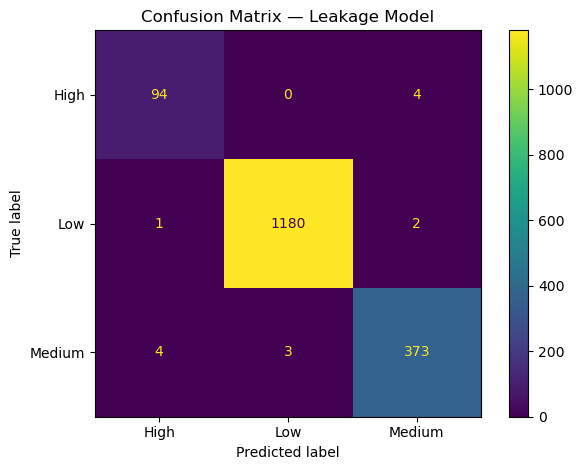

In [6]:
# ============================================================
# Columns
# ============================================================

TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain","Temperature","Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month","Year"]

# LEAKAGE VARIABLES
LEAK_COLS = ["Dengue Cases"]

# ============================================================
# Build Dataset
# ============================================================

X = df[
    CLIMATE_COLS +
    SOCIO_COLS +
    ENV_COLS +
    TIME_COLS +
    LEAK_COLS
].copy()

y = df[TARGET_COL].astype(str)

# -----------------------------
# Numeric columns
# -----------------------------

numeric_cols = [
    "Rain","Temperature","Relative Humidity",

    "Dengue Cases",

    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",

    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",

    "Month","Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# -----------------------------
# Categorical columns
# -----------------------------

cat_cols = ["Municipal Class","Settlement Type","Flood Hazard Level"]

for c in cat_cols:
    X[c] = X[c].astype(str)

X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# -----------------------------
# Encode Target
# -----------------------------

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Leakage Model")
print("Classes:",class_names)
print("X shape:",X.shape)

# ============================================================
# Train/Test Split
# ============================================================

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# ============================================================
# XGBoost + Hyperparameter Tuning
# ============================================================

model = XGBClassifier(
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {

    "n_estimators":[500,800,1200],

    "max_depth":[3,4,5,6,8],

    "learning_rate":[0.03,0.05,0.08,0.1],

    "subsample":[0.7,0.85,1.0],

    "colsample_bytree":[0.7,0.85,1.0],

    "min_child_weight":[1,2,4,6,8],

    "gamma":[0,0.5,1,2],

    "reg_alpha":[0,0.1,0.5,1],

    "reg_lambda":[1,2,5,10]

}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:",round(search.best_score_,4))
print("Best params:",search.best_params_)

# ============================================================
# Evaluation
# ============================================================

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print("\nHold-out accuracy:",round(acc,4))

print("\nClassification Report")
print(classification_report(y_test,y_pred,target_names=class_names))

cm = confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(cm,display_labels=class_names).plot(values_format="d")

plt.title("Confusion Matrix — Leakage Model")

plt.tight_layout()

plt.show()